# 08 - Estimação do ATE (RQ1)

**RQ1: Qual o efeito causal médio de cada estratégia de balanceamento sobre o
desempenho do classificador, comparado a não balancear (`none`)?**

**Dois estimadores, por construção do desfecho**
- **Efeito vs `none` (RQ1):** o ΔY **já é relativo ao `none`** do próprio grupo, logo
  o DoWhy **não se aplica** aqui - o ΔY do `none` é 0 por construção e degenera o
  estimador. Usa-se o estimador equivalente do livro, *backdoor via regressão linear*
  (uma regressão linear de ΔY sobre a estratégia + o contexto Z), com IC por
  **cluster bootstrap** por grupo.
- **Contraste entre estratégias ativas (over vs cost_sensitive):** ambos os braços têm
  ΔY não degenerado, então aqui roda o **DoWhy completo** (`CausalModel` →
  `identify_effect` → `estimate_effect`), exatamente o idioma do livro.

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dowhy import CausalModel

NB_DIR        = Path().resolve()
PROJECT_DIR   = NB_DIR.parent if NB_DIR.name == "notebooks" else NB_DIR
PROCESSED_DIR = PROJECT_DIR / "data" / "processed"

df = pd.read_parquet(PROCESSED_DIR / "analysis_dataset.parquet")

STRATS     = ["oversampling", "cost_sensitive", "undersampling", "other"]
PRINCIPAIS = {"oversampling", "cost_sensitive"} # São os com volume relevante
RNG        = np.random.default_rng(42)

print(f"Pares: {len(df)} | grupos: {df['within_paper_group_id'].nunique()}")
print(df["strategy"].value_counts().reindex(STRATS).to_string())

Pares: 425 | grupos: 279
strategy
oversampling      156
cost_sensitive     79
undersampling      32
other             158


## 1. Preparação do desfecho e de Z

ΔY tem cauda longa (ganhos muito grandes sobre baselines minúsculos). Estimamos em ΔY
**winsorizado** nos percentis 1/99 e em ΔY bruto, só para manter comparação. A ideia de winsorizar é substituir os outliers de ΔY acima ou abaixo de certos percentis pelo valor do próprio percentil.

Por que não simplesmente apagar os outliers? winsorizar preserva o tamanho da amostra e a informação do tipo "esse caso teve ganho muito grande", já que ele vira o teto, em vez de jogar a linha fora.

In [2]:
lo, hi = df["delta_y"].quantile([0.01, 0.99])
df["delta_y_w"] = df["delta_y"].clip(lo, hi)
print(f"Winsorização 1/99: [{lo:.3f}, {hi:.3f}] | pares ajustados: {(df['delta_y'] != df['delta_y_w']).sum()}")

COMMON = ["ir_bin", "nclasses_bin", "size_bin", "task3", "model_family3"]  # confundidores Z
# Categorias fixadas a partir da base completa -> matriz de design estável no bootstrap.
CAT_COLS = ["strategy"] + COMMON
CATS = {c: sorted(df[c].dropna().unique()) for c in CAT_COLS}
print("Ajuste backdoor por Z:", COMMON)

Winsorização 1/99: [-0.619, 11.134] | pares ajustados: 10
Ajuste backdoor por Z: ['ir_bin', 'nclasses_bin', 'size_bin', 'task3', 'model_family3']


## 2. RQ1 - efeito vs `none`: regressão linear de ΔY com padronização (g-fórmula)

Aqui a gente ajusta uma regressão linear de ΔY em função da estratégia + Z (é o que o
livro chama de *backdoor via regressão linear*). Para achar o efeito médio de cada
estratégia a gente usa a g-fórmula: fixa `strategy = s` em **todas** as linhas e tira a
média da predição sobre a distribuição de Z. Como o ΔY já é relativo ao `none`, essa
média ajustada é o ganho relativo médio sobre o baseline.

In [3]:
def make_design(data):
    d = data.copy()
    for c in CAT_COLS:
        d[c] = pd.Categorical(d[c], categories=CATS[c])
    X = pd.get_dummies(d[CAT_COLS], drop_first=True).astype(float)
    X.insert(0, "intercept", 1.0)
    return X.values

def adjusted_means(data, outcome):
    X = make_design(data)
    y = data[outcome].to_numpy(dtype=float)
    beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    out = {}
    for s in STRATS:
        d = data.copy(); d["strategy"] = s
        out[s] = float((make_design(d) @ beta).mean())
    return out

point_wins = adjusted_means(df, "delta_y_w")
point_raw  = adjusted_means(df, "delta_y")
unadj      = df.groupby("strategy")["delta_y_w"].mean().reindex(STRATS).to_dict()

print(f"{'estratégia':<16}{'bruta(nao-aj)':>14}{'ajust.(wins)':>14}{'ajust.(raw)':>14}")
for s in STRATS:
    print(f"{s:<16}{unadj[s]*100:>13.1f}%{point_wins[s]*100:>13.1f}%{point_raw[s]*100:>13.1f}%")

estratégia       bruta(nao-aj)  ajust.(wins)   ajust.(raw)
oversampling             46.2%         32.6%         42.0%
cost_sensitive           10.5%         24.3%         27.2%
undersampling            30.8%         32.4%         48.3%
other                    34.5%         40.7%         89.0%


## 3. Incerteza: cluster bootstrap por grupo

O ponto estimado acima é só um número; a gente também quer saber o quão confiável ele é.
A ideia do **bootstrap** é simular "e se a gente tivesse coletado uma amostra um pouco
diferente?". Em vez de sair coletando dados novos (que a gente não tem), o truque é
reamostrar **com reposição** a própria base que já temos: monta-se uma base nova do mesmo
tamanho sorteando linhas da original, recalcula-se o efeito, e repete isso muitas vezes
(aqui ~1000). No fim sobra uma distribuição de efeitos, e o intervalo de confiança de 95%
é só pegar os percentis 2,5 e 97,5 dessa distribuição.

**Por que reamostrar por grupo e não linha por linha?** As linhas da nossa base não são
independentes: vários pares (estratégia vs `none`) vêm do **mesmo paper / mesmo grupo**, e
resultados do mesmo paper tendem a se parecer (mesmos dados, mesmo setup, mesmos vieses).
Se a gente sorteasse linha por linha, estaria fingindo ter mais informação independente do
que realmente tem, e o intervalo sairia **mais estreito que a verdade** (otimista demais).
O **cluster bootstrap** corrige isso reamostrando o **grupo inteiro** (`within_paper_group_id`)
como unidade: sorteia-se um grupo com reposição e leva-se **todas** as linhas dele juntas.
Assim a correlação intra-paper é preservada e o IC reflete a incerteza de verdade.

Na prática, no código abaixo: a gente quebra a base num dicionário `grupo -> linhas`,
sorteia IDs de grupo com reposição (a mesma quantidade de grupos que existe), cola as
linhas desses grupos numa base nova e roda a mesma `adjusted_means` em cima dela. Cada
iteração dá um efeito por estratégia; juntando as ~1000 iterações, tiramos os percentis
para o IC95%.

In [4]:
def cluster_bootstrap(data, outcome, n_boot=1000):
    groups = {g: d for g, d in data.groupby("within_paper_group_id")}
    gids = np.array(list(groups.keys()))
    draws = {s: [] for s in STRATS}
    for _ in range(n_boot):
        ids  = RNG.choice(gids, size=len(gids), replace=True)
        boot = pd.concat([groups[g] for g in ids], ignore_index=True)
        m = adjusted_means(boot, outcome)
        for s in STRATS:
            draws[s].append(m[s])
    return {s: (np.percentile(draws[s], 2.5), np.percentile(draws[s], 97.5)) for s in STRATS}

ci_wins = cluster_bootstrap(df, "delta_y_w", n_boot=1000)

rows = []
for s in STRATS:
    eff, (lo_, hi_) = point_wins[s] * 100, (ci_wins[s][0] * 100, ci_wins[s][1] * 100)
    rows.append({
        "estratégia": s,
        "n": int((df["strategy"] == s).sum()),
        "efeito % (wins.)": round(eff, 2),
        "IC95% baixo": round(lo_, 2),
        "IC95% alto": round(hi_, 2),
        "cruza 0?": "sim" if lo_ <= 0 <= hi_ else "NÃO",
        "papel": "principal" if s in PRINCIPAIS else "exploratório",
    })
ate = pd.DataFrame(rows)
print(ate.to_string(index=False))
ate.to_csv(PROCESSED_DIR / "ate_resultados.csv", index=False)
print("\nSalvo: data/processed/ate_resultados.csv")

    estratégia   n  efeito % (wins.)  IC95% baixo  IC95% alto cruza 0?        papel
  oversampling 156             32.58        15.73       51.84      NÃO    principal
cost_sensitive  79             24.28         7.47       49.25      NÃO    principal
 undersampling  32             32.37       -22.06      109.03      sim exploratório
         other 158             40.70        16.73       72.71      NÃO exploratório

Salvo: data/processed/ate_resultados.csv


## 4. Forest plot - efeito de cada estratégia vs `none`

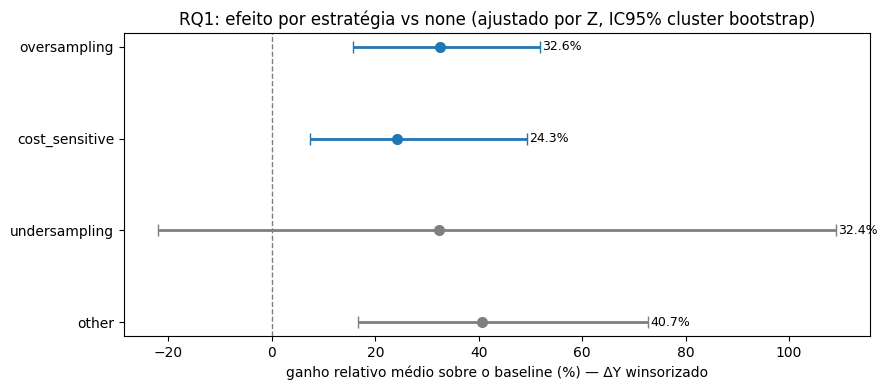

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4))
ypos = np.arange(len(STRATS))[::-1]
for y, s in zip(ypos, STRATS):
    eff = point_wins[s] * 100
    lo_, hi_ = ci_wins[s][0] * 100, ci_wins[s][1] * 100
    color = "C0" if s in PRINCIPAIS else "C7"
    ax.errorbar(eff, y, xerr=[[eff - lo_], [hi_ - eff]], fmt="o",
                color=color, capsize=4, lw=2, markersize=7)
    ax.text(hi_ + 0.5, y, f"{eff:.1f}%", va="center", fontsize=9)
ax.axvline(0, color="gray", ls="--", lw=1)
ax.set_yticks(ypos); ax.set_yticklabels(STRATS)
ax.set_xlabel("ganho relativo médio sobre o baseline (%) - ΔY winsorizado")
ax.set_title("RQ1: efeito por estratégia vs none (ajustado por Z, IC95% cluster bootstrap)")
plt.tight_layout()
plt.show()